In [17]:
!pip install xgboost

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from xgboost import XGBClassifier
import joblib

import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
from google.colab import files
# Load dataset
df = pd.read_csv('/content/multicast_dataset.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3500, 38)


,frame_time_relative,frame_time_delta,frame_len,frame_number,ip_proto,ip_ttl,ip_hdr_len,ip_len,ip_flags,ip_frag,...,is_pim,pim_type,icmp_type,icmp_code,is_icmp,pkt_rate_10,avg_size_10,std_size_10,igmp_ratio_10,Label
0,0.000000,0.000000,28,1,2,1,20,28,0,0,...,0,0,0,0,0,0.000000,0.0,0.0,0.0,0
1,0.000979,0.000979,28,2,2,1,20,28,0,0,...,0,0,0,0,0,1000.000000,28.0,0.0,1.0,0
2,0.000979,0.000000,28,3,2,1,20,28,0,0,...,0,0,0,0,0,2042.514731,28.0,0.0,1.0,0
3,0.000979,0.000000,28,4,2,1,20,28,0,0,...,0,0,0,0,0,3063.772096,28.0,0.0,1.0,0
4,0.000979,0.000000,28,5,2,1,20,28,0,0,...,0,0,0,0,0,4085.029462,28.0,0.0,1.0,0


In [19]:
# Remove NaN / inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# Check class distribution
label_map = {
    0: 'Benign',
    1: 'IGMP Flood',
    2: 'IGMP Spoof',
    3: 'MLD Flood',
    4: 'PIM Manip',
    5: 'Amplification',
    6: 'Group Scan'
}
class_distribution = df['Label'].value_counts().rename(index=label_map)
print(class_distribution)

Label
Benign           500
IGMP Flood       500
IGMP Spoof       500
MLD Flood        500
PIM Manip        500
Amplification    500
Group Scan       500
Name: count, dtype: int64


In [20]:
X = df.drop('Label', axis=1)
y = df['Label']

print("Features:", X.shape)
print("Labels:", y.shape)

Features: (3500, 37)
Labels: (3500,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 THIS IS IMPORTANT
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain distribution:\n", y_train.value_counts())
print("\nTest distribution:\n", y_test.value_counts())

Train: (2800, 37)
Test : (700, 37)

Train distribution:
 Label
2    400
1    400
4    400
3    400
0    400
6    400
5    400
Name: count, dtype: int64

Test distribution:
 Label
2    100
1    100
4    100
0    100
6    100
3    100
5    100
Name: count, dtype: int64


In [22]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [23]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [24]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [26]:
y_pred = model.predict(X_test)

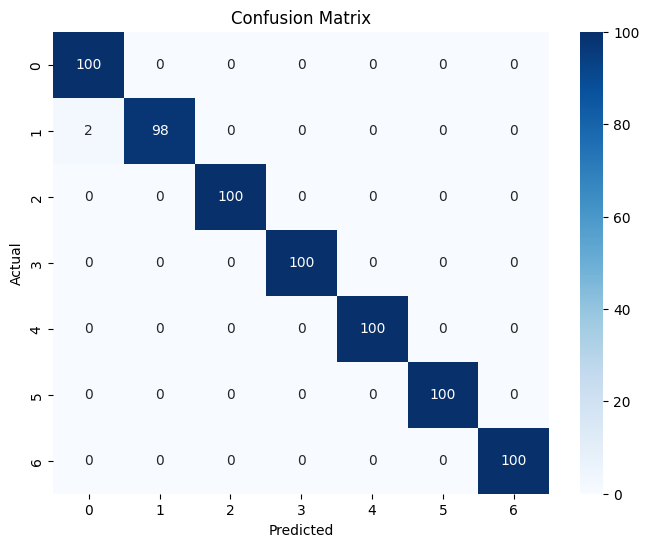

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
label_map = {
    'Benign':        0,
    'IGMP Flood':    1,
    'IGMP Spoof':    2,
    'MLD Flood':     3,
    'PIM Manip':     4,
    'Amplification': 5,
    'Group Scan':    6
}

# Invert the dictionary to map numerical labels back to names for reporting
target_names = {v: k for k, v in label_map.items()}
target_names_list = [target_names[i] for i in sorted(target_names.keys())]

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate and print classification report
report = classification_report(y_test, y_pred, target_names=target_names_list, digits=4)
print(report)

Accuracy: 0.9971
               precision    recall  f1-score   support

       Benign     0.9804    1.0000    0.9901       100
   IGMP Flood     1.0000    0.9800    0.9899       100
   IGMP Spoof     1.0000    1.0000    1.0000       100
    MLD Flood     1.0000    1.0000    1.0000       100
    PIM Manip     1.0000    1.0000    1.0000       100
Amplification     1.0000    1.0000    1.0000       100
   Group Scan     1.0000    1.0000    1.0000       100

     accuracy                         0.9971       700
    macro avg     0.9972    0.9971    0.9971       700
 weighted avg     0.9972    0.9971    0.9971       700



                Feature  Importance
30            icmp_type    0.188772
2             frame_len    0.188772
24        igmp_is_query    0.186452
17            igmp_type    0.186450
20      igmp_gaddr_oct4    0.130623
22         igmp_is_join    0.077365
19      igmp_gaddr_oct3    0.039782
0   frame_time_relative    0.000900
33          pkt_rate_10    0.000460
3          frame_number    0.000364
21   igmp_group_entropy    0.000059
4              ip_proto    0.000000
1      frame_time_delta    0.000000
12     dst_is_multicast    0.000000
11          ip_dst_oct4    0.000000


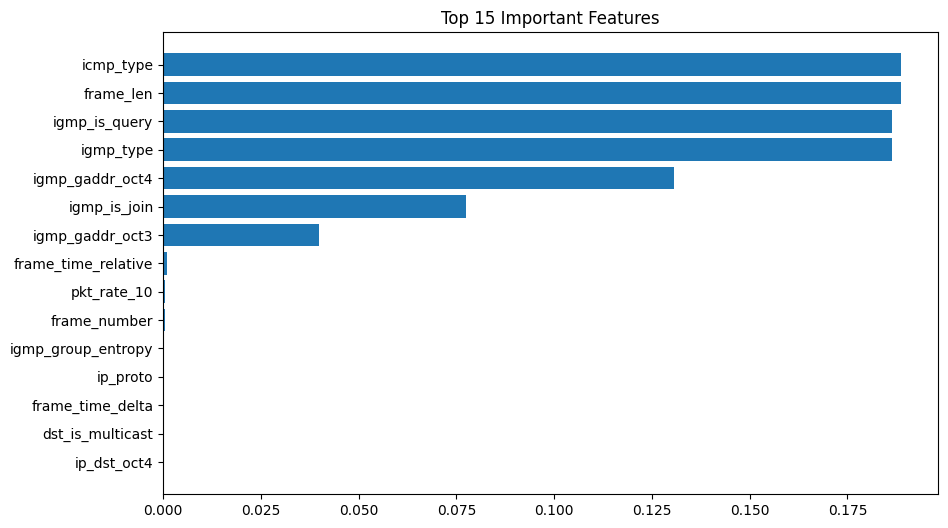

In [29]:
importance = model.feature_importances_

feat_names = X.columns

imp_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(imp_df.head(15))

# Plot
plt.figure(figsize=(10,6))
plt.barh(imp_df['Feature'][:15], imp_df['Importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.show()

In [30]:
joblib.dump(model, "xgboost_multicast.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved!")

Model saved!
